<a href="https://colab.research.google.com/github/harshini-sudharsan/International-Finance-ER-ICA/blob/main/IF_ICA_Harsh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

general imports:


In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import coint_johansen

granger causality imports:

In [3]:
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests

xgboost imports:

In [4]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

data imports:

In [5]:
brent    = pd.read_csv('brent.csv',    index_col='Date')
vix      = pd.read_csv('cboe_vix.csv', index_col='Date')
fed_int  = pd.read_csv('fed_int.csv',  index_col='Date',usecols=['Date', 'fed_rate'])
ind_repo = pd.read_csv('ind_repo.csv', index_col='Date')
ind_cpi  = pd.read_csv('indcpi.csv',   index_col='Date')
us_cpi   = pd.read_csv('uscpi.csv',    index_col='Date')
usdinr   = pd.read_csv('usdinr.csv',   index_col='Date')

In [6]:
brent.columns    = ['oil']
vix.columns      = ['vix']
fed_int.columns  = ['rate_us']
ind_repo.columns = ['rate_in']
ind_cpi.columns  = ['cpi_in']
us_cpi.columns   = ['cpi_us']
usdinr.columns   = ['usd_inr']

# merge on common dates (inner join keeps only dates present in ALL files)
df = brent.join([vix, fed_int, ind_repo, ind_cpi, us_cpi, usdinr], how='inner')

print(df.shape)

(109, 7)


PPP:

finding interest rate differential

In [7]:
df['inf_diff']  = np.log(df['cpi_in']).diff(12) - np.log(df['cpi_us']).diff(12)

In [8]:
df['rate_diff'] = df['rate_in'] - df['rate_us']
df['fx_change'] = np.log(df['usd_inr']).diff()
df['fx_lag1']   = df['usd_inr'].shift(1)
df.dropna(inplace=True)
df['inf_diff'].describe()

,inf_diff
count,97.000000
mean,0.016045
std,0.024229
min,-0.030115
25%,0.000324
50%,0.011901
75%,0.031593
max,0.069118


Testing for stationarity:

In [9]:
variables = ['usd_inr', 'cpi_in', 'cpi_us', 'rate_in', 'rate_us', 'inf_diff', 'rate_diff', 'fx_change']

for var in variables:
    result = adfuller(df[var].dropna())
    pval = result[1]
    stationary = 'stationary' if pval < 0.05 else 'non-stationary'
    print(f"{var:<12} | p-value: {pval:.4f} | {stationary}")

usd_inr      | p-value: 0.9340 | non-stationary
cpi_in       | p-value: 0.8263 | non-stationary
cpi_us       | p-value: 0.9057 | non-stationary
rate_in      | p-value: 0.2622 | non-stationary
rate_us      | p-value: 0.5325 | non-stationary
inf_diff     | p-value: 0.5259 | non-stationary
rate_diff    | p-value: 0.8739 | non-stationary
fx_change    | p-value: 0.0008 | stationary


Taking first difference to try and remove the nonstationarity:

In [10]:
df['inf_diff_d']  = df['inf_diff'].diff()
df['rate_diff_d'] = df['rate_diff'].diff()
df.dropna(inplace=True)
print(df['inf_diff_d'])

# retest just these two
for var in ['inf_diff_d', 'rate_diff_d']:
    result = adfuller(df[var].dropna())
    stationary = 'stationary' if pval < 0.05 else 'non-stationary'
    print(f"{var:<14} | p-value: {pval:.4f} | {stationary}")

Date
01-04-2017   -0.001371
01-05-2017   -0.007910
01-06-2017    0.002112
01-07-2017    0.006053
01-08-2017    0.005246
                ...   
01-11-2024   -0.006423
01-12-2024   -0.004849
01-01-2025   -0.005367
01-02-2025   -0.003175
01-03-2025    0.007701
Name: inf_diff_d, Length: 96, dtype: float64
inf_diff_d     | p-value: 0.0008 | stationary
rate_diff_d    | p-value: 0.0008 | stationary


PPP testing: does the inflation differential explain the ER changes?

In [11]:
X = sm.add_constant(df['inf_diff_d'])
y = df['fx_change']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              fx_change   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.2981
Date:                Sun, 29 Mar 2026   Prob (F-statistic):              0.586
Time:                        08:12:32   Log-Likelihood:                 290.73
No. Observations:                  96   AIC:                            -577.5
Df Residuals:                      94   BIC:                            -572.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0029      0.001      2.364      0.0

In [12]:
#ppp is not shown to hold in the 10 year period. only applicable in very long periods of time, with low intervention in exchange rates.

Now, to test the cointegration of given variables using Johansen Coint Test.


*The Johansen cointegration test is a statistical method used to determine if a long-term equilibrium relationship (cointegration) exists between two or more non-stationary time series variables. It identifies the number of cointegrating vectors, allowing for multiple, complex long-run relationships among several variables simultaneously.*



In [13]:
johansen_data = pd.DataFrame({
    'log_usd_inr' : np.log(df['usd_inr']),
    'log_cpi_in'  : np.log(df['cpi_in']),
    'log_cpi_us'  : np.log(df['cpi_us'])
})

result = coint_johansen(johansen_data, det_order=0, k_ar_diff=1)

print("Trace statistics:", result.lr1)
print("Critical values (90%, 95%, 99%):\n", result.cvt)

Trace statistics: [20.06673421  5.12998271  0.15564977]
Critical values (90%, 95%, 99%):
 [[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [14]:
#er and infl and int of india only
johansen_t2 = pd.DataFrame({
    'log_usd_inr' : np.log(df['usd_inr']),
    'log_cpi_in'  : np.log(df['cpi_in']),
    'log_rate_in'  : np.log(df['rate_in'])
})

result = coint_johansen(johansen_t2, det_order=0, k_ar_diff=1)

print("Trace statistics:", result.lr1)
print("Critical values (90%, 95%, 99%):\n", result.cvt)

Trace statistics: [16.46130868  3.96928489  0.88025375]
Critical values (90%, 95%, 99%):
 [[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


There is purchasing power difference between India and US, and our data indicates the latter to have higher purchasing power,meaning the same amount of money buys more goods and services in India than in the US.

Moving on to Granger Causality test:
*"does knowing past values of inflation/interest rates help predict future exchange rate movements?"*

In [15]:
granger_data = df[['fx_change','rate_in','rate_us']]

# fit VAR and select optimal lag
model = VAR(granger_data)
lag_selection = model.select_order(maxlags=6)
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -26.95      -26.87   1.973e-12      -26.92
1      -34.31      -33.97   1.261e-15      -34.17
2      -35.02     -34.44*   6.179e-16      -34.79
3     -35.20*      -34.37  5.176e-16*     -34.86*
4      -35.15      -34.07   5.458e-16      -34.71
5      -35.07      -33.73   5.972e-16      -34.53
6      -35.05      -33.46   6.144e-16      -34.41
-------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [16]:
#trying for just indian cpi and int rate:
df['cpi_in_d'] = df['cpi_in'].diff()
df['rate_in_d'] = df['rate_in'].diff()
# test 1: does India inflation Granger-cause FX?
print("=== Does India inflation Granger-cause USD/INR? ===")
grangercausalitytests(df[['fx_change', 'cpi_in_d']].dropna(), maxlag=3)

# test 2: does India interest rate Granger-cause FX?
print("=== Does India interest rate Granger-cause USD/INR? ===")
grangercausalitytests(df[['fx_change', 'rate_in_d']].dropna(), maxlag=3)

=== Does India inflation Granger-cause USD/INR? ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0128  , p=0.9103  , df_denom=91, df_num=1
ssr based chi2 test:   chi2=0.0132  , p=0.9086  , df=1
likelihood ratio test: chi2=0.0132  , p=0.9086  , df=1
parameter F test:         F=0.0128  , p=0.9103  , df_denom=91, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0430  , p=0.9579  , df_denom=88, df_num=2
ssr based chi2 test:   chi2=0.0909  , p=0.9556  , df=2
likelihood ratio test: chi2=0.0908  , p=0.9556  , df=2
parameter F test:         F=0.0430  , p=0.9579  , df_denom=88, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0871  , p=0.9669  , df_denom=85, df_num=3
ssr based chi2 test:   chi2=0.2829  , p=0.9632  , df=3
likelihood ratio test: chi2=0.2825  , p=0.9633  , df=3
parameter F test:         F=0.0871  , p=0.9669  , df_denom=85, df_num=3
=== Does India interest rate Granger-cause USD/I

{np.int64(1): ({'ssr_ftest': (np.float64(0.27099541195064436),
    np.float64(0.6039291451897122),
    np.float64(91.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.279929326630336),
    np.float64(0.5967475422919182),
    np.int64(1)),
   'lrtest': (np.float64(0.27951334150020557),
    np.float64(0.5970203674386284),
    np.int64(1)),
   'params_ftest': (np.float64(0.2709954119506605),
    np.float64(0.6039291451896988),
    np.float64(91.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.585727056617085),
    np.float64(0.21059438525853266),
    np.float64(88.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(3.3516503696679294),
    np.float64(0.1871536793673137),
    np.int64(2)),
   'lrtest': (np.float64(3.2926678329667993),
    np.float64(0.19275527179525037),
    np.int64(2)),
   'params_ftest': (np.float64(1.5857270566170902),
    np.float64(0.21059438525853266),
    np.float64(88.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
       

In [17]:
grangercausalitytests(df[['fx_change', 'inf_diff_d']], maxlag=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5079  , p=0.4779  , df_denom=92, df_num=1
ssr based chi2 test:   chi2=0.5245  , p=0.4689  , df=1
likelihood ratio test: chi2=0.5230  , p=0.4696  , df=1
parameter F test:         F=0.5079  , p=0.4779  , df_denom=92, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2770  , p=0.7587  , df_denom=89, df_num=2
ssr based chi2 test:   chi2=0.5851  , p=0.7464  , df=2
likelihood ratio test: chi2=0.5833  , p=0.7470  , df=2
parameter F test:         F=0.2770  , p=0.7587  , df_denom=89, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.2733  , p=0.8445  , df_denom=86, df_num=3
ssr based chi2 test:   chi2=0.8867  , p=0.8286  , df=3
likelihood ratio test: chi2=0.8825  , p=0.8296  , df=3
parameter F test:         F=0.2733  , p=0.8445  , df_denom=86, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(0.5078914233936048),
    np.float64(0.4778567017883564),
    np.float64(92.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.5244531002433963),
    np.float64(0.4689482730252532),
    np.int64(1)),
   'lrtest': (np.float64(0.5230107689969827),
    np.float64(0.4695601917652553),
    np.int64(1)),
   'params_ftest': (np.float64(0.5078914233936072),
    np.float64(0.4778567017883564),
    np.float64(92.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.2769859261173038),
    np.float64(0.7587162257489037),
    np.float64(89.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.5850938664050913),
    np.float64(0.7463602151387063),
    np.int64(2)),
   'lrtest': (np.float64(0.5832804574798729),
    np.float64(0.7470372501654434),
    np.int64(2)),
   'params_ftest': (np.float64(0.27698592611730327),
    np.float64(0.7587162257489037),
    np.float64(89.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
         

In [18]:
grangercausalitytests(df[['fx_change', 'rate_diff_d']], maxlag=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2010  , p=0.6550  , df_denom=92, df_num=1
ssr based chi2 test:   chi2=0.2075  , p=0.6487  , df=1
likelihood ratio test: chi2=0.2073  , p=0.6489  , df=1
parameter F test:         F=0.2010  , p=0.6550  , df_denom=92, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2011  , p=0.8182  , df_denom=89, df_num=2
ssr based chi2 test:   chi2=0.4249  , p=0.8086  , df=2
likelihood ratio test: chi2=0.4239  , p=0.8090  , df=2
parameter F test:         F=0.2011  , p=0.8182  , df_denom=89, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.4466  , p=0.7203  , df_denom=86, df_num=3
ssr based chi2 test:   chi2=1.4488  , p=0.6941  , df=3
likelihood ratio test: chi2=1.4376  , p=0.6967  , df=3
parameter F test:         F=0.4466  , p=0.7203  , df_denom=86, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(0.20095806670684996),
    np.float64(0.655002604719739),
    np.float64(92.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.20751104714294288),
    np.float64(0.6487252534340229),
    np.int64(1)),
   'lrtest': (np.float64(0.20728474066277158),
    np.float64(0.6489039717333225),
    np.int64(1)),
   'params_ftest': (np.float64(0.20095806670683325),
    np.float64(0.6550026047197473),
    np.float64(92.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.20113174634672001),
    np.float64(0.8181753735642614),
    np.float64(89.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.424862565316667),
    np.float64(0.8086158803460513),
    np.int64(2)),
   'lrtest': (np.float64(0.42390529868112026),
    np.float64(0.8090030034852913),
    np.int64(2)),
   'params_ftest': (np.float64(0.2011317463467135),
    np.float64(0.8181753735642696),
    np.float64(89.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
      

no granger-causal relationships found :(

Moving onto XGBoost Regression:

In [19]:
df

,oil,vix,rate_us,rate_in,cpi_in,cpi_us,usd_inr,inf_diff,rate_diff,fx_change,fx_lag1,inf_diff_d,rate_diff_d,cpi_in_d,rate_in_d
Date,,,,,,,,,,,,,,,
01-04-2017,52.31,13.14,0.0090,0.0650,105.96,244.19,64.540000,0.000324,0.0560,-0.019335,65.800000,-0.001371,-0.0036,NaN,NaN
01-05-2017,50.33,10.86,0.0091,0.0650,106.34,244.00,64.419545,-0.007586,0.0559,-0.001868,64.540000,-0.007910,-0.0001,0.38,0.0000
01-06-2017,46.37,10.51,0.0104,0.0650,107.11,244.16,64.448182,-0.005474,0.0546,0.000444,64.419545,0.002112,-0.0013,0.77,0.0000
01-07-2017,48.48,10.26,0.0115,0.0650,109.02,244.24,64.420000,0.000579,0.0535,-0.000437,64.448182,0.006053,-0.0011,1.91,0.0000
01-08-2017,51.70,11.98,0.0116,0.0625,109.02,245.18,63.968261,0.005825,0.0509,-0.007037,64.420000,0.005246,-0.0026,0.00,-0.0025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
01-11-2024,74.35,16.02,0.0464,0.0625,159.20,316.53,84.332632,0.011259,0.0161,0.003893,84.005000,-0.006423,0.0019,0.00,0.0000
01-12-2024,73.86,15.87,0.0448,0.0600,158.32,317.60,84.968571,0.006410,0.0152,0.007513,84.332632,-0.004849,-0.0009,-0.88,-0.0025
01-01-2025,79.27,16.76,0.0433,0.0600,157.77,318.96,86.265238,0.001043,0.0167,0.015145,84.968571,-0.005367,0.0015,-0.55,0.0000


In [20]:
features = ['inf_diff_d', 'rate_diff_d', 'oil', 'vix']
X = df[features]
y = df['usd_inr']

# train/test split - keep time order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# fit model
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model_xgb.fit(X_train, y_train)

# evaluate
y_pred = model_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")

RMSE: 3.3203
MAE:  2.5160
R²: 0.7597


In [21]:
features = ['inf_diff_d', 'rate_diff_d', 'oil', 'vix']
X = df[features]
y = df['fx_change']

# train/test split - keep time order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# fit model
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model_xgb.fit(X_train_scaled, y_train)

# evaluate
y_pred = model_xgb.predict(X_test_scaled)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

RMSE: 0.0090
MAE:  0.0074
R²:   -0.2094


In [22]:
X_ols = sm.add_constant(df[['inf_diff_d', 'rate_diff_d', 'oil', 'vix']])
y_ols = df['fx_change']

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              fx_change   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     3.827
Date:                Sun, 29 Mar 2026   Prob (F-statistic):            0.00639
Time:                        08:12:32   Log-Likelihood:                 298.04
No. Observations:                  96   AIC:                            -586.1
Df Residuals:                      91   BIC:                            -573.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0162      0.006     -2.733      

In [23]:
X_uip = sm.add_constant(df['rate_diff_d'])
y_uip = df['fx_change']

uip_model = sm.OLS(y_uip, X_uip).fit()
print(uip_model.summary())

                            OLS Regression Results                            
Dep. Variable:              fx_change   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     2.522
Date:                Sun, 29 Mar 2026   Prob (F-statistic):              0.116
Time:                        08:12:32   Log-Likelihood:                 291.85
No. Observations:                  96   AIC:                            -579.7
Df Residuals:                      94   BIC:                            -574.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0034      0.001      2.742      

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


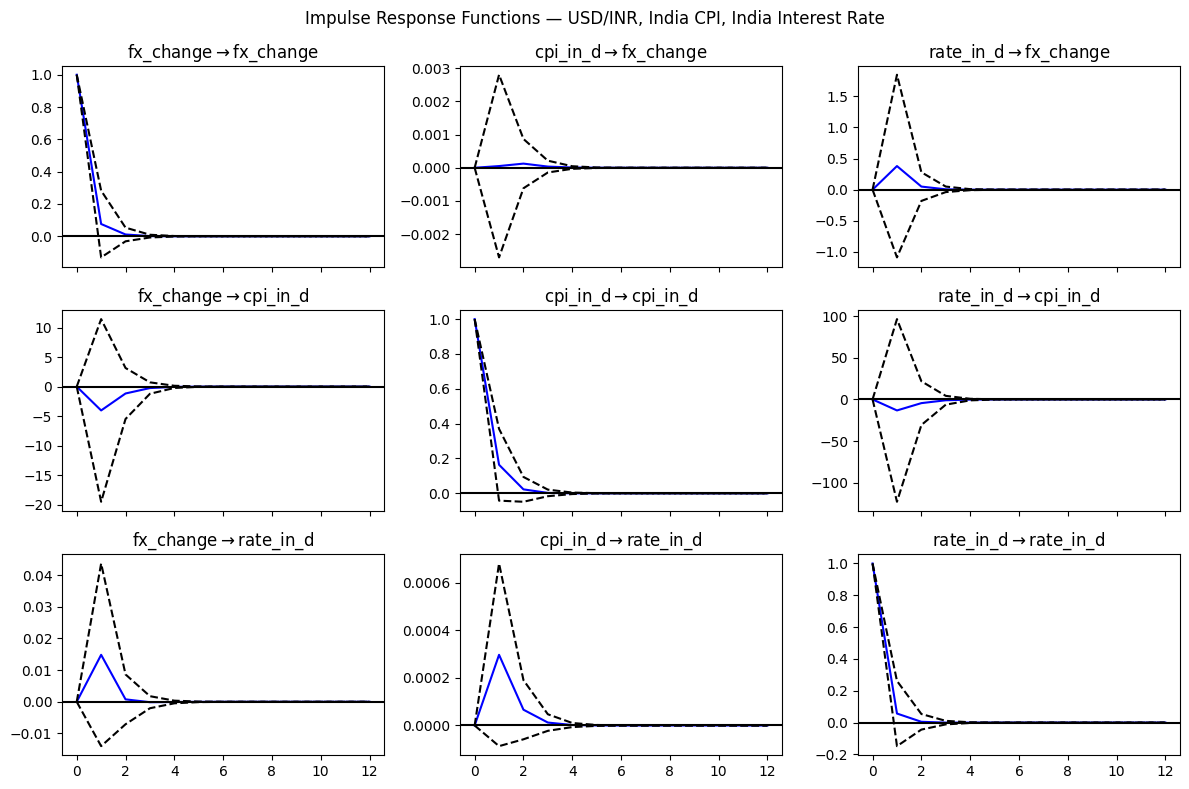

In [24]:
from statsmodels.tsa.vector_ar.var_model import VAR
import matplotlib.pyplot as plt

var_data = df[['fx_change', 'cpi_in_d', 'rate_in_d']].dropna()

# fit VAR at lag 1
var_model = VAR(var_data)
results = var_model.fit(1)

# impulse response over 12 months
irf = results.irf(12)

# plot
irf.plot(orth=False, figsize=(12, 8))
plt.suptitle('Impulse Response Functions — USD/INR, India CPI, India Interest Rate', fontsize=12)
plt.tight_layout()
plt.show()

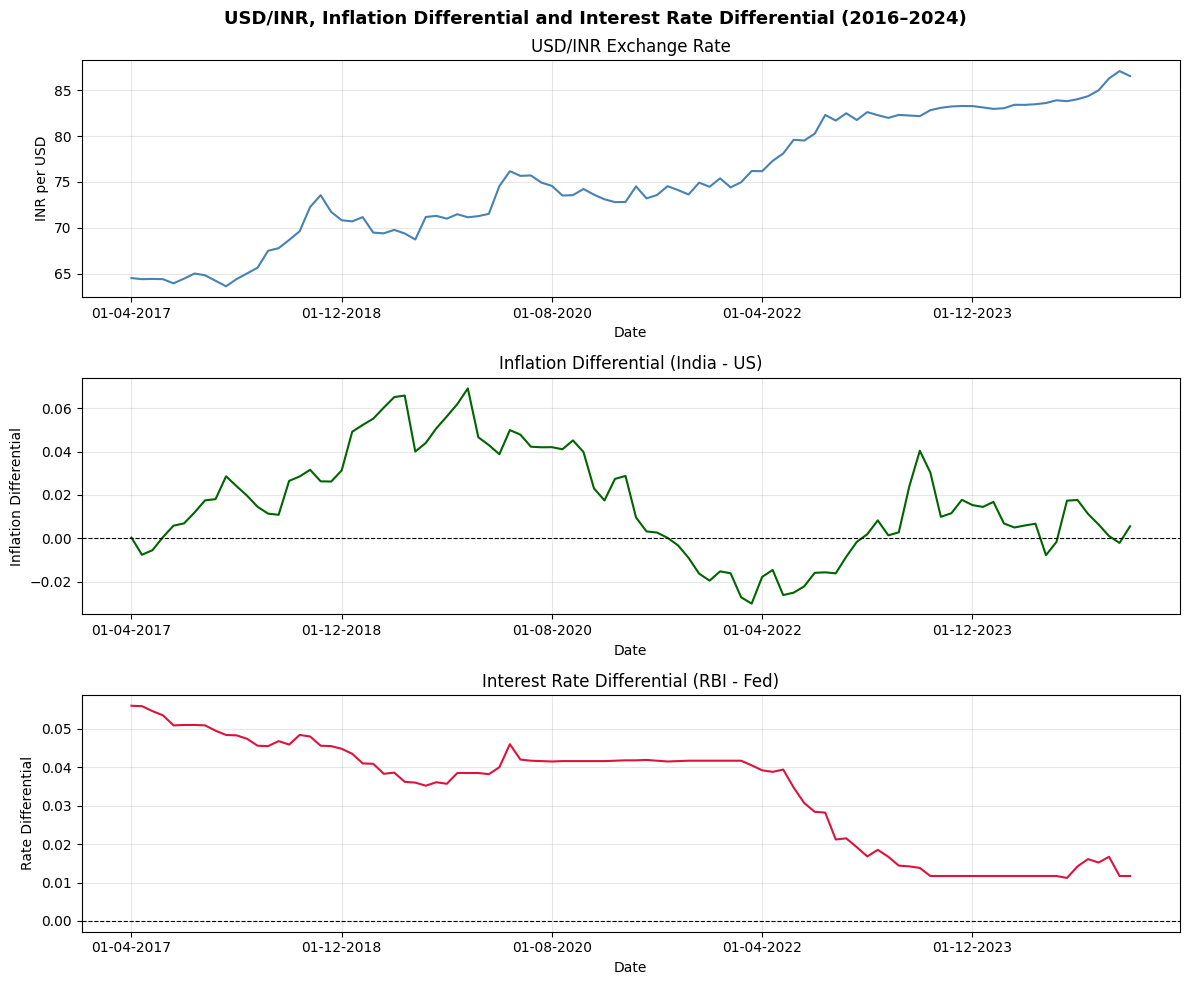

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

df['usd_inr'].plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('USD/INR Exchange Rate')
axes[0].set_ylabel('INR per USD')
axes[0].grid(alpha=0.3)

df['inf_diff'].plot(ax=axes[1], color='darkgreen', linewidth=1.5)
axes[1].set_title('Inflation Differential (India - US)')
axes[1].set_ylabel('Inflation Differential')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(alpha=0.3)

df['rate_diff'].plot(ax=axes[2], color='crimson', linewidth=1.5)
axes[2].set_title('Interest Rate Differential (RBI - Fed)')
axes[2].set_ylabel('Rate Differential')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].grid(alpha=0.3)

plt.suptitle('USD/INR, Inflation Differential and Interest Rate Differential (2016–2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

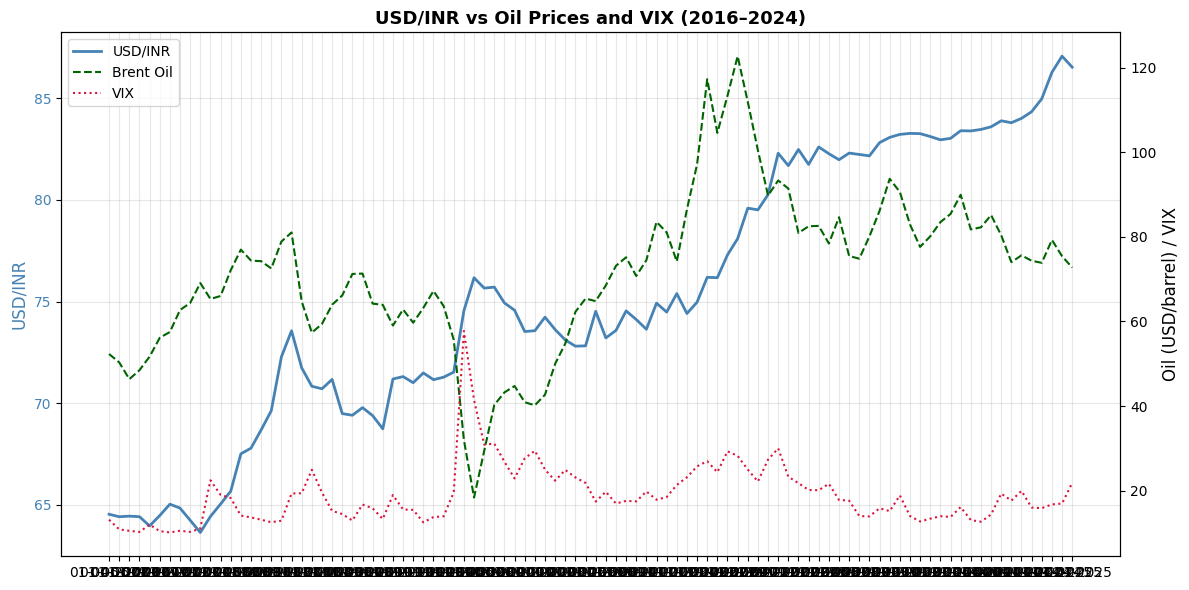

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# USD/INR on primary axis
ax1.plot(df.index, df['usd_inr'], color='steelblue', linewidth=2, label='USD/INR')
ax1.set_ylabel('USD/INR', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Oil on secondary axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['oil'], color='darkgreen', linewidth=1.5, linestyle='--', label='Brent Oil')
ax2.plot(df.index, df['vix'], color='crimson', linewidth=1.5, linestyle=':', label='VIX')
ax2.set_ylabel('Oil (USD/barrel) / VIX', color='black', fontsize=12)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.set_title('USD/INR vs Oil Prices and VIX (2016–2024)', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
#trying with reserve transactions and gdp growth:
macro = pd.read_excel("final_macro_dataset.xlsx", index_col="Date")
macro.head()

,GVA,FI,reserve_rs
Date,,,
01-01-2015,6.717710,11108.109118,2031370.0
01-02-2015,6.717710,6988.973906,2088260.0
01-03-2015,6.717710,4896.649420,2137640.0
01-04-2015,9.436547,8063.772379,2210960.0
01-05-2015,9.436547,2153.233631,2243720.0


In [28]:
macro_new = pd.merge(df, macro, on='Date', how='left')

In [39]:
macro_new.drop(columns = ["fx_lag1","cpi_us","cpi_in_d","rate_in_d"])
x_mac = sm.add_constant(macro_new[["vix","GVA","FI","reserve_rs","rate_in"]])
y_mac = macro_new["fx_change"]
mac_model = sm.OLS(y_mac, x_mac).fit()
print(mac_model.summary())

                            OLS Regression Results                            
Dep. Variable:              fx_change   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     5.135
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           0.000345
Time:                        11:05:52   Log-Likelihood:                 302.63
No. Observations:                  96   AIC:                            -593.3
Df Residuals:                      90   BIC:                            -577.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0107      0.013     -0.799      0.4

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Variable"] = x_mac.columns
vif_data["VIF"] = [variance_inflation_factor(x_mac.values, i) for i in range(x_mac.shape[1])]

print(vif_data)

     Variable         VIF
0       const  149.709492
1         vix    1.985375
2         GVA    1.235474
3          FI    1.234893
4  reserve_rs    1.095832
5     rate_in    1.655396


In [34]:
rolling_corr = macro_new['fx_change'].rolling(12).corr(macro_new['vix'])
print(rolling_corr)

Date
01-04-2017         NaN
01-05-2017         NaN
01-06-2017         NaN
01-07-2017         NaN
01-08-2017         NaN
                ...   
01-11-2024    0.519214
01-12-2024    0.408544
01-01-2025    0.298536
01-02-2025    0.263226
01-03-2025   -0.191175
Length: 96, dtype: float64
